In [2]:
from pathlib import Path
import pandas as pd

from tmatch_triplets import index_images, build_triplets, write_manifest, sort_key

BEFORE_DIR = Path(r"C:\shared\CG\ЧИ\До")
AFTER_DIR = Path(r"C:\shared\CG\ЧИ\После")
OUTPUT_DIR = Path("outputs/tmatch")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

before_images = index_images(BEFORE_DIR)
after_images = index_images(AFTER_DIR)

triplets = build_triplets(before_images, after_images, seed=42)
write_manifest(OUTPUT_DIR / "tmatch_triplets_manifest.csv", triplets)

before_ids = set(before_images)
after_ids = set(after_images)

print("До:", len(before_images))
print("После:", len(after_images))
print("Реальных пар:", len(before_ids & after_ids))
print("Только в До:", len(before_ids - after_ids), sorted(before_ids - after_ids, key=sort_key)[:20])
print("Только в После:", len(after_ids - before_ids), sorted(after_ids - before_ids, key=sort_key)[:20])
print("Троек:", len(triplets))

manifest_df = pd.DataFrame([
    {
        "pair_id": t.pair_id,
        "before_path": str(t.before_path),
        "after_path": str(t.after_path),
        "negative_id": t.negative_id,
        "negative_path": str(t.negative_path),
    }
    for t in triplets
])


До: 6436
После: 8118
Реальных пар: 6435
Только в До: 1 ['5334']
Только в После: 1683 ['3', '11', '13', '14', '18', '23', '27', '29', '37', '45', '47', '49', '50', '53', '54', '55', '56', '58', '60', '61']
Троек: 6435


In [2]:
from pathlib import Path

from tmatch_triplets import (
    KeypointMatcher,
    read_existing_results,
    read_manifest,
    select_device,
    write_results,
)

OUTPUT_DIR = Path("outputs/tmatch")
MANIFEST_CSV = OUTPUT_DIR / "tmatch_triplets_manifest.csv"
RESULTS_CSV = OUTPUT_DIR / "tmatch_keypoint_counts.csv"

triplets = read_manifest(MANIFEST_CSV)

rows = read_existing_results(RESULTS_CSV)
done = {row["pair_id"] for row in rows}

matcher = KeypointMatcher(
    device=select_device(None),
    max_keypoints=2048,
    max_side=1024,
)

for n, t in enumerate(triplets, start=1):
    if t.pair_id in done:
        continue

    positive_matches = matcher.count_matches(t.before_path, t.after_path)
    negative_matches = matcher.count_matches(t.before_path, t.negative_path)

    rows.append({
        "pair_id": t.pair_id,
        "before_path": str(t.before_path),
        "after_path": str(t.after_path),
        "negative_id": t.negative_id,
        "negative_path": str(t.negative_path),
        "positive_matches": positive_matches,
        "negative_matches": negative_matches,
    })

    write_results(RESULTS_CSV, rows)
    print(f"{n}/{len(triplets)} id={t.pair_id} pos={positive_matches} neg={negative_matches}")

print("saved:", RESULTS_CSV)

21/6435 id=28 pos=24 neg=20
22/6435 id=30 pos=146 neg=118
23/6435 id=31 pos=549 neg=46
24/6435 id=32 pos=34 neg=34
25/6435 id=33 pos=335 neg=39
26/6435 id=34 pos=220 neg=36
27/6435 id=35 pos=309 neg=17
28/6435 id=36 pos=18 neg=30
29/6435 id=38 pos=1100 neg=22
30/6435 id=39 pos=691 neg=17
31/6435 id=40 pos=252 neg=57
32/6435 id=41 pos=259 neg=51
33/6435 id=42 pos=361 neg=48
34/6435 id=43 pos=631 neg=20
35/6435 id=44 pos=721 neg=22
36/6435 id=46 pos=82 neg=48
37/6435 id=48 pos=438 neg=26
38/6435 id=51 pos=36 neg=14
39/6435 id=52 pos=472 neg=72
40/6435 id=57 pos=87 neg=30
41/6435 id=59 pos=103 neg=48
42/6435 id=62 pos=5 neg=32
43/6435 id=63 pos=750 neg=6
44/6435 id=64 pos=706 neg=86
45/6435 id=65 pos=465 neg=30
46/6435 id=66 pos=71 neg=29
47/6435 id=67 pos=650 neg=34
48/6435 id=69 pos=139 neg=25
49/6435 id=72 pos=726 neg=17
50/6435 id=76 pos=963 neg=44
51/6435 id=77 pos=32 neg=38
52/6435 id=79 pos=62 neg=43
53/6435 id=80 pos=324 neg=15
54/6435 id=82 pos=119 neg=46
55/6435 id=84 pos=615 ne

c:\Users\USER\ZeroShotCleaningAssessment\.venv\Lib\site-packages\PIL\Image.py:3451: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


220/6435 id=335 pos=50 neg=71
221/6435 id=336 pos=710 neg=42
222/6435 id=337 pos=51 neg=84
223/6435 id=338 pos=710 neg=63
224/6435 id=339 pos=478 neg=43
225/6435 id=342 pos=522 neg=25
226/6435 id=343 pos=536 neg=49
227/6435 id=344 pos=498 neg=10
228/6435 id=345 pos=70 neg=40
229/6435 id=346 pos=378 neg=5
230/6435 id=347 pos=36 neg=41
231/6435 id=348 pos=752 neg=66
232/6435 id=349 pos=1012 neg=64
233/6435 id=350 pos=1012 neg=64
234/6435 id=351 pos=611 neg=27
235/6435 id=352 pos=622 neg=98
236/6435 id=353 pos=441 neg=36
237/6435 id=355 pos=737 neg=36
238/6435 id=356 pos=641 neg=8
239/6435 id=357 pos=134 neg=47
240/6435 id=358 pos=737 neg=50
241/6435 id=359 pos=788 neg=24
242/6435 id=360 pos=49 neg=34
243/6435 id=361 pos=452 neg=59
244/6435 id=362 pos=304 neg=29
245/6435 id=363 pos=473 neg=32
246/6435 id=364 pos=613 neg=60
247/6435 id=365 pos=1275 neg=38
248/6435 id=366 pos=932 neg=49
249/6435 id=367 pos=437 neg=48
250/6435 id=368 pos=613 neg=51
251/6435 id=369 pos=49 neg=33
252/6435 id=3

Лучший порог по F1
Tmatch: 80
F1: 0.829075
Precision: 0.957274
Recall: 0.731158
FN: 1730
FP: 210
TP: 4705
TN: 6225
Errors: 1940
Accuracy: 0.849262


,threshold,fn,fp,tp,tn,errors,accuracy,precision,recall,f1,fn_rate,fp_rate
81,80,1730,210,4705,6225,1940,0.849262,0.957274,0.731158,0.829075,0.268842,0.032634
80,79,1716,230,4719,6205,1946,0.848796,0.953526,0.733333,0.829058,0.266667,0.035742
85,84,1779,144,4656,6291,1923,0.850583,0.970000,0.723543,0.828838,0.276457,0.022378
84,83,1769,159,4666,6276,1928,0.850194,0.967047,0.725097,0.828774,0.274903,0.024709
83,82,1759,175,4676,6260,1934,0.849728,0.963925,0.726651,0.828637,0.273349,0.027195
79,78,1707,250,4728,6185,1957,0.847941,0.949779,0.734732,0.828529,0.265268,0.038850
82,81,1747,194,4688,6241,1941,0.849184,0.960262,0.728516,0.828488,0.271484,0.030148
75,74,1643,342,4792,6093,1985,0.845765,0.933385,0.744678,0.828421,0.255322,0.053147
87,86,1803,117,4632,6318,1920,0.850816,0.975363,0.719814,0.828326,0.280186,0.018182
88,87,1810,109,4625,6326,1919,0.850894,0.976975,0.718726,0.828185,0.281274,0.016939


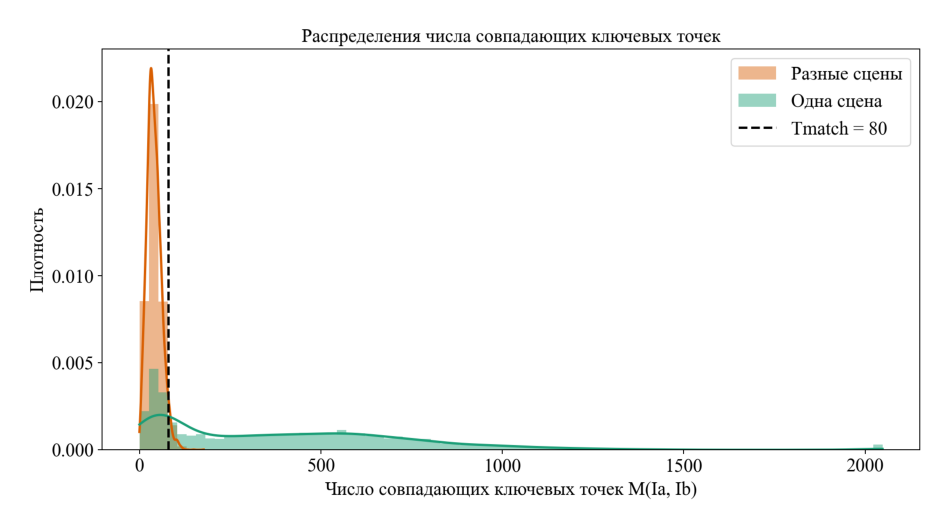

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from evaluate_tmatch import (
    read_match_counts,
    evaluate_thresholds,
    select_best_f1_thresholds,
    choose_representative_threshold,
    plot_distributions,
)

counts_csv = Path("outputs/tmatch/tmatch_keypoint_counts.csv")

positive, negative = read_match_counts(counts_csv)

rows = evaluate_thresholds(positive, negative)
df = pd.DataFrame(rows)

best_f1_rows = select_best_f1_thresholds(rows)
best = choose_representative_threshold(best_f1_rows)

print("Лучший порог по F1")
print("Tmatch:", best["threshold"])
print("F1:", round(best["f1"], 6))
print("Precision:", round(best["precision"], 6))
print("Recall:", round(best["recall"], 6))
print("FN:", best["fn"])
print("FP:", best["fp"])
print("TP:", best["tp"])
print("TN:", best["tn"])
print("Errors:", best["errors"])
print("Accuracy:", round(best["accuracy"], 6))

display(
    df.sort_values("f1", ascending=False)
    .head(10)
    [[
        "threshold",
        "fn",
        "fp",
        "tp",
        "tn",
        "errors",
        "accuracy",
        "precision",
        "recall",
        "f1",
        "fn_rate",
        "fp_rate",
    ]]
)

plot_path = counts_csv.parent / "tmatch_distributions_f1.png"
plot_distributions(
    plot_path,
    positive=positive,
    negative=negative,
    threshold=int(best["threshold"]),
)

img = plt.imread(plot_path)
plt.figure(figsize=(12, 7))
plt.imshow(img)
plt.axis("off")
plt.show()